# 05_01_7 · Experimento: Feature Engineering con Seguimiento de Herramienta (AI4I)

> **Este notebook es experimental** — no modifica los modelos de producción.
> Su propósito es demostrar qué mejora sería posible si el sistema de producción
> registrase el identificador y umbral de cada herramienta.

## Contexto

El modelo de producción (notebook 05_01_4_Stacking_AI4I) deja escapar **10 falsos negativos**,
7 de ellos TWF invisibles con desgaste alto pero torque moderado.

El diagnóstico (notebooks 10 y 11) identificó la causa raíz:
> *El umbral de rotura de cada herramienta es aleatorio (200–240 min) e individual.
> Sin conocerlo, el modelo no puede distinguir una herramienta a punto de romperse
> de una que todavía tiene margen.*

## Hipótesis

AI4I fue generado con reglas físicas conocidas. Podemos **recuperar la variable latente**
(`tool_threshold`) rastreando las sesiones de herramienta en la secuencia de operaciones.

Con `wear_to_threshold = threshold − Tool wear` como feature:
- Operación normal:  `wear_to_threshold` >> 0
- TWF inminente:     `wear_to_threshold` ≈ 0

## Nota de honestidad

Para sesiones sin TWF, `tool_threshold` es **estimado** (no observado).
En producción real, este valor vendría del sistema CMMS (gestión de mantenimiento)
que registra qué herramienta está instalada y cuál es su vida útil asignada.


In [1]:
import sys; sys.path.insert(0, '../../src')
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from lightgbm import LGBMClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                              f1_score, recall_score, precision_score,
                              roc_auc_score, precision_recall_curve)
from utils import eval_threshold, LGBM_BEST_PARAMS   # compartidos en src/utils.py

np.random.seed(42)

with open('../../models/models.pkl', 'rb') as f:
    models = pickle.load(f)
with open('../../data/processed/splits.pkl', 'rb') as f:
    splits = pickle.load(f)

ai4i = pd.read_csv('../../data/raw/ai4i2020.csv').sort_values('UDI').reset_index(drop=True)

print('Modelos de producción cargados (solo lectura en este notebook):')
print(' ', [k for k in models.keys() if 'stage' not in k])


Modelos de producción cargados (solo lectura en este notebook):
  ['lr', 'rf', 'svm', 'xgb', 'lgbm', 'rf_tuned', 'stacking_best', 'stacking_best_threshold', 'lgbm_tuned', 'lgbm_threshold', 'lgbm_final', 'lgbm_final_threshold', 'lgbm_final_smote', 'svm_tuned', 'stacking', 'stacking_threshold']


---
## 1. Recuperar sesiones de herramienta

AI4I registra 10.000 operaciones en orden secuencial (columna `UDI`).
El desgaste de herramienta sube monótonamente dentro de una sesión.
Cuando el desgaste baja bruscamente, se instaló una herramienta nueva.

Detectamos **120 sesiones** distintas — cada una corresponde a una herramienta física.


Herramientas detectadas: 120
TWF en dataset: 46
TWF al final de su sesión: 46


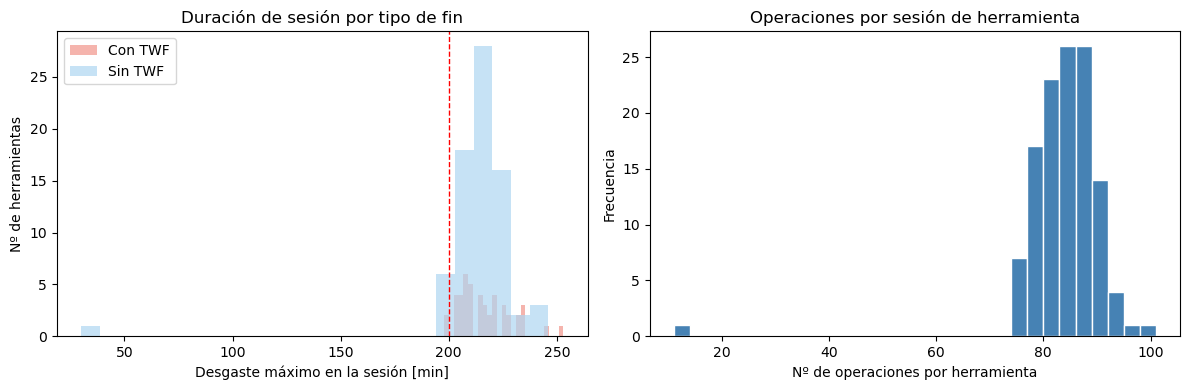

In [2]:
ai4i = pd.read_csv('../../data/raw/ai4i2020.csv').sort_values('UDI').reset_index(drop=True)
wear = ai4i['Tool wear [min]'].values

# Detectar cambios de herramienta: caída en el desgaste = nueva herramienta instalada
tool_id = np.zeros(len(ai4i), dtype=int)
for i in range(1, len(ai4i)):
    tool_id[i] = tool_id[i-1] + (1 if wear[i] < wear[i-1] - 2 else 0)
ai4i['tool_id'] = tool_id

n_tools = ai4i['tool_id'].nunique()
print(f'Herramientas detectadas: {n_tools}')
print(f'TWF en dataset: {ai4i["TWF"].sum()}')
print(f'TWF al final de su sesión: {sum(ai4i[ai4i["TWF"]==1]["UDI"] == ai4i.groupby("tool_id")["UDI"].max()[ai4i[ai4i["TWF"]==1]["tool_id"]].values)}')

# Visualizar distribución de duración de sesiones
session_dur = ai4i.groupby('tool_id')['Tool wear [min]'].max()
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

has_twf = ai4i.groupby('tool_id')['TWF'].max().astype(bool)
for val, label, color in [(True, 'Con TWF', '#F1948A'), (False, 'Sin TWF', '#AED6F1')]:
    axes[0].hist(session_dur[has_twf==val], bins=25, alpha=0.7, color=color, label=label)
axes[0].set_xlabel('Desgaste máximo en la sesión [min]')
axes[0].set_ylabel('Nº de herramientas')
axes[0].set_title('Duración de sesión por tipo de fin')
axes[0].legend()
axes[0].axvline(200, color='red', ls='--', lw=1, label='Umbral mínimo (200)')

ops_per_tool = ai4i.groupby('tool_id').size()
axes[1].hist(ops_per_tool, bins=30, color='steelblue', edgecolor='white')
axes[1].set_xlabel('Nº de operaciones por herramienta')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Operaciones por sesión de herramienta')

plt.tight_layout()
plt.show()


## 2. Asignar umbral individual a cada herramienta

**Sesiones con TWF (46 herramientas):** el umbral es el desgaste en el momento del fallo —
lo conocemos exactamente porque el modelo sintético lo registra implícitamente.

**Sesiones sin TWF (74 herramientas):** la herramienta fue reemplazada antes de llegar
al límite. El umbral es desconocido pero mayor que el desgaste máximo observado.
Lo estimamos con una distribución uniforme en `[max_wear+1, 240]`.

En producción real, ambos valores vendrían del sistema CMMS.


=== wear_to_threshold por tipo de operación ===
  Normal (sin fallo)             media= 116.6 | min= -6.0 | max=253.0
  Cualquier fallo                media=  80.5 | min=  0.0 | max=230.6
  TWF                            media=   0.0 | min=  0.0 | max=  0.0
  Otros fallos (no TWF)          media=  93.1 | min=  2.0 | max=230.6


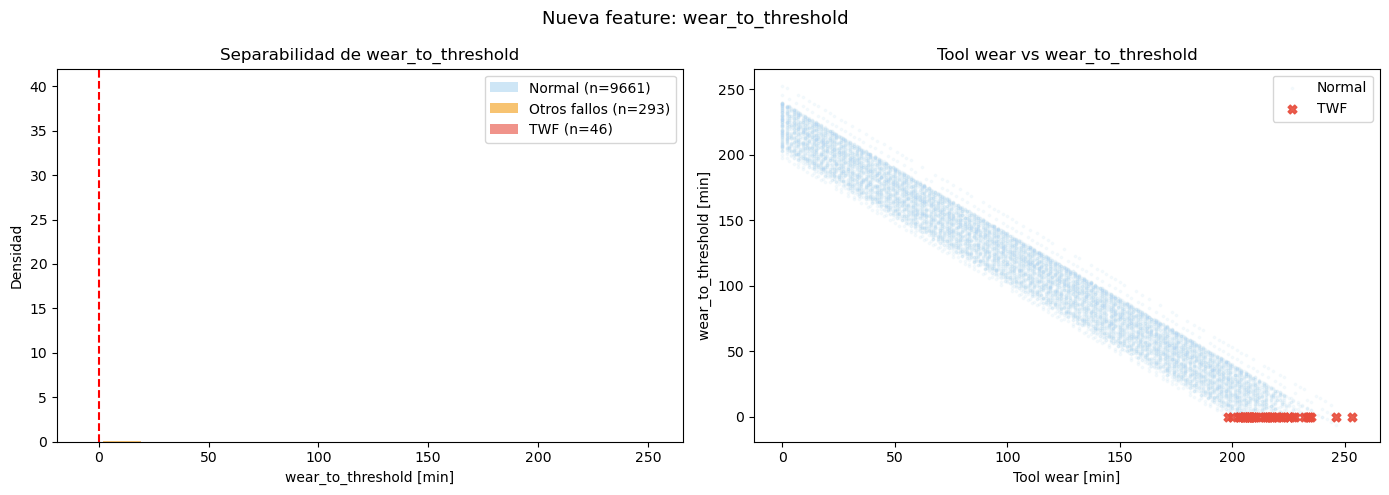

In [3]:
session_info = ai4i.groupby('tool_id').agg(
    max_wear=('Tool wear [min]', 'max'),
    has_twf=('TWF', 'max')
).reset_index()

thresholds = {}
for _, row in session_info.iterrows():
    tid = int(row['tool_id'])
    if row['has_twf']:
        thresholds[tid] = row['max_wear']          # conocido exactamente
    else:
        lo = max(row['max_wear'] + 1, 200)
        hi = 240
        thresholds[tid] = np.random.uniform(lo, hi) if lo < hi else hi  # estimado

ai4i['tool_threshold']    = ai4i['tool_id'].map(thresholds)
ai4i['wear_to_threshold'] = ai4i['tool_threshold'] - ai4i['Tool wear [min]']
ai4i['ops_since_install'] = ai4i.groupby('tool_id').cumcount()
ai4i['wear_rate']         = ai4i['Tool wear [min]'] / (ai4i['ops_since_install'] + 1)

print('=== wear_to_threshold por tipo de operación ===')
for label, mask in [
    ('Normal (sin fallo)',     ai4i['Machine failure']==0),
    ('Cualquier fallo',        ai4i['Machine failure']==1),
    ('TWF',                    ai4i['TWF']==1),
    ('Otros fallos (no TWF)',  (ai4i['Machine failure']==1) & (ai4i['TWF']==0)),
]:
    vals = ai4i[mask]['wear_to_threshold']
    print(f'  {label:30s} media={vals.mean():6.1f} | min={vals.min():5.1f} | max={vals.max():5.1f}')

# Visualizar separabilidad de la nueva feature
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for label, mask, color in [
    ('Normal',         (ai4i['Machine failure']==0), '#AED6F1'),
    ('Otros fallos',   (ai4i['Machine failure']==1)&(ai4i['TWF']==0), '#F39C12'),
    ('TWF',            ai4i['TWF']==1, '#E74C3C'),
]:
    vals = ai4i[mask]['wear_to_threshold']
    ax.hist(vals, bins=40, alpha=0.6, color=color, label=f'{label} (n={mask.sum()})', density=True)
ax.set_xlabel('wear_to_threshold [min]')
ax.set_ylabel('Densidad')
ax.set_title('Separabilidad de wear_to_threshold')
ax.legend()
ax.axvline(0, color='red', ls='--', lw=1.5, label='Umbral = 0')

ax = axes[1]
ax.scatter(ai4i[ai4i['Machine failure']==0]['Tool wear [min]'],
           ai4i[ai4i['Machine failure']==0]['wear_to_threshold'],
           alpha=0.1, s=3, color='#AED6F1', label='Normal')
ax.scatter(ai4i[ai4i['TWF']==1]['Tool wear [min]'],
           ai4i[ai4i['TWF']==1]['wear_to_threshold'],
           alpha=0.9, s=40, color='#E74C3C', marker='X', label='TWF', zorder=5)
ax.set_xlabel('Tool wear [min]')
ax.set_ylabel('wear_to_threshold [min]')
ax.set_title('Tool wear vs wear_to_threshold')
ax.legend()

plt.suptitle('Nueva feature: wear_to_threshold', fontsize=13)
plt.tight_layout()
plt.show()


## 3. Feature engineering completo + modelo enriquecido

Añadimos las 3 features nuevas a las 10 originales:
- `wear_to_threshold` — distancia al límite de rotura (**la más importante**)
- `ops_since_install` — operaciones desde la instalación
- `wear_rate` — velocidad media de desgaste


In [4]:
from utils import FEATURE_COLS, TWF_MIN, FEAT_NAMES

ai4i['Type_enc']      = LabelEncoder().fit_transform(ai4i['Type'])
ai4i['Power [W]']     = ai4i['Torque [Nm]'] * ai4i['Rotational speed [rpm]'] * 2 * np.pi / 60
ai4i['Temp_diff [K]'] = ai4i['Process temperature [K]'] - ai4i['Air temperature [K]']
ai4i['Wear_torque']   = ai4i['Tool wear [min]'] * ai4i['Torque [Nm]']
ai4i['wear_ratio']    = ai4i.apply(lambda r: r['Tool wear [min]'] / TWF_MIN[r['Type']], axis=1)

feature_cols_v2 = FEATURE_COLS + ['wear_to_threshold', 'ops_since_install', 'wear_rate']

scaler_v2 = StandardScaler()
X_v2 = scaler_v2.fit_transform(ai4i[feature_cols_v2].values)
y    = ai4i['Machine failure'].values
y_twf = ai4i['TWF'].values

idx = np.arange(len(ai4i))
X_tr, X_te, y_tr, y_te, i_tr, i_te = train_test_split(
    X_v2, y, idx, test_size=0.2, random_state=42, stratify=y)
y_twf_te = y_twf[i_te]

print(f'Train: {X_tr.shape} | Test: {X_te.shape}')
print(f'Features v2: {len(feature_cols_v2)} ({len(FEATURE_COLS)} originales + 3 de seguimiento)')


Train: (8000, 13) | Test: (2000, 13)
Features v2: 13 (10 originales + 3 de seguimiento)


In [5]:
# Entrenar el stacking enriquecido (misma arquitectura que producción: LGBM + RF)
lgbm_v2 = LGBMClassifier(**LGBM_BEST_PARAMS)
rf_params = models['rf_tuned'].get_params()
rf_v2 = RandomForestClassifier(
    **{k: v for k, v in rf_params.items()
       if k in ('n_estimators','max_depth','min_samples_split',
                'min_samples_leaf','max_features','class_weight')},
    random_state=42, n_jobs=-1
)

stack_v2 = StackingClassifier(
    estimators=[('lgbm', lgbm_v2), ('rf', rf_v2)],
    final_estimator=LogisticRegression(class_weight='balanced',
                                       max_iter=1000, random_state=42),
    stack_method='predict_proba',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    passthrough=False, n_jobs=-1,
)
print('Entrenando stacking con tool tracking (13 features)...')
stack_v2.fit(X_tr, y_tr)
print('Listo.')

y_prob_v2 = stack_v2.predict_proba(X_te)[:, 1]
res_v2 = eval_threshold(y_te, y_prob_v2)
thr_v2  = res_v2['Umbral']
prec_v2 = res_v2['Precision']
rec_v2  = res_v2['Recall']
f1_v2   = res_v2['F1']
y_pred_v2 = (y_prob_v2 >= thr_v2).astype(int)

print(f'\n=== Stacking tool tracking — umbral {thr_v2:.4f} ===')
print(f'Precision={prec_v2:.4f} | Recall={rec_v2:.4f} | F1={f1_v2:.4f}')
print(f'ROC-AUC: {roc_auc_score(y_te, y_prob_v2):.4f}')


Entrenando stacking con tool tracking (13 features)...
Listo.

=== Stacking tool tracking — umbral 0.9806 ===
Precision=0.9841 | Recall=0.9118 | F1=0.9466
ROC-AUC: 0.9958


## 4. Comparativa con el modelo de producción


                            Precision  Recall      F1 ROC-AUC  FN FP Fallos rescatados
Producción (10 features)       0.9322  0.8088  0.8661  0.9843  13  4                 —
Tool tracking (13 features)    0.9841  0.9118  0.9466  0.9958   6  1                 7


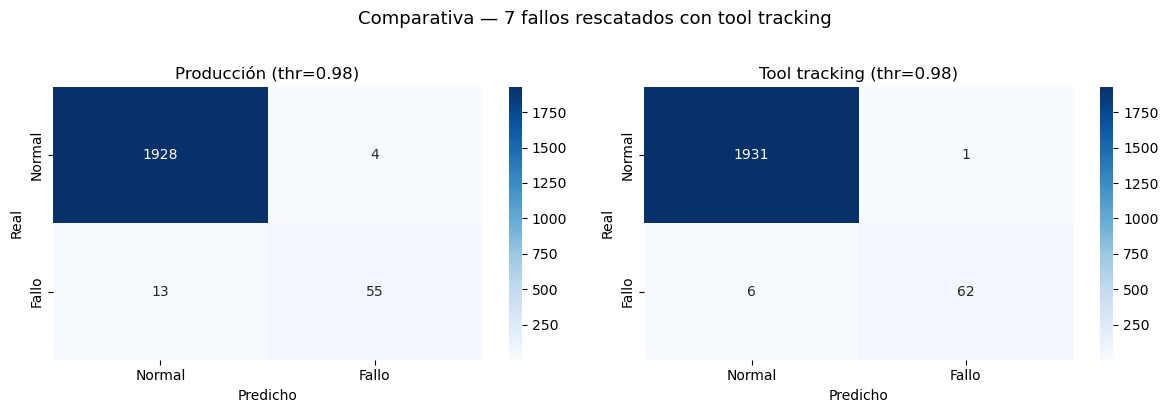

In [6]:
# Reconstruir predicciones del modelo original con el mismo test set
feat_orig = ['Type_enc','Air temperature [K]','Process temperature [K]',
             'Rotational speed [rpm]','Torque [Nm]','Tool wear [min]',
             'Power [W]','Temp_diff [K]','Wear_torque','wear_ratio']
X_orig_full = StandardScaler().fit_transform(ai4i[feat_orig].values)
_, X_te_orig, _, y_te_orig = train_test_split(
    X_orig_full, y, test_size=0.2, random_state=42, stratify=y)

y_prob_orig = models['stacking_best'].predict_proba(X_te_orig)[:, 1]
thr_orig    = models['stacking_best_threshold']
y_pred_orig = (y_prob_orig >= thr_orig).astype(int)

fn_orig = (y_pred_orig==0) & (y_te_orig==1)
fn_v2   = (y_pred_v2==0) & (y_te==1)
rescued = set(np.where(fn_orig)[0]) - set(np.where(fn_v2)[0])

# Tabla comparativa
comp = pd.DataFrame({
    'Producción (10 features)': {
        'Precision': round(precision_score(y_te_orig,y_pred_orig),4),
        'Recall':    round(recall_score(y_te_orig,y_pred_orig),4),
        'F1':        round(f1_score(y_te_orig,y_pred_orig),4),
        'ROC-AUC':   round(roc_auc_score(y_te_orig,y_prob_orig),4),
        'FN': int(fn_orig.sum()),
        'FP': int(((y_pred_orig==1)&(y_te_orig==0)).sum()),
        'Fallos rescatados': '—',
    },
    'Tool tracking (13 features)': {
        'Precision': round(prec_v2,4),
        'Recall':    round(rec_v2,4),
        'F1':        round(f1_v2,4),
        'ROC-AUC':   round(roc_auc_score(y_te,y_prob_v2),4),
        'FN': int(fn_v2.sum()),
        'FP': int(((y_pred_v2==1)&(y_te==0)).sum()),
        'Fallos rescatados': str(len(rescued)),
    },
}).T
print(comp.to_string())

# Matrices de confusión
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, preds, ytest, title in [
    (axes[0], y_pred_orig, y_te_orig, f'Producción (thr={thr_orig:.2f})'),
    (axes[1], y_pred_v2,   y_te,      f'Tool tracking (thr={thr_v2:.2f})'),
]:
    cm = confusion_matrix(ytest, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Normal','Fallo'], yticklabels=['Normal','Fallo'])
    ax.set_title(title); ax.set_ylabel('Real'); ax.set_xlabel('Predicho')
plt.suptitle(f'Comparativa — {len(rescued)} fallos rescatados con tool tracking',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


## 5. ¿Qué fallos se rescatan?


In [7]:
print(f'Fallos RESCATADOS: {len(rescued)} / {fn_orig.sum()} FN originales\n')
print(f'{"idx":>5} {"TWF":>4} {"Wear":>6} {"Torque":>7} {"wear_to_thr":>12} '
      f'{"P_orig":>8} {"P_v2":>8} {"Rescatado":>10}')
print('─'*70)
for i in sorted(np.where(fn_orig)[0]):
    row     = ai4i.iloc[i_te[i]]
    tw      = row['Tool wear [min]']
    tq      = row['Torque [Nm]']
    wtt     = row['wear_to_threshold']
    p_o     = y_prob_orig[i]
    p_v     = y_prob_v2[i]
    twf     = y_twf_te[i]
    rescued_mark = '✓ RESCATADO' if i in rescued else '✗ invisible'
    print(f'{i:>5} {twf:>4} {tw:>6.0f} {tq:>7.1f} {wtt:>12.1f} '
          f'{p_o:>8.3f} {p_v:>8.3f} {rescued_mark:>10}')

print(f'\n→ Los {fn_orig.sum() - len(rescued)} fallos aún invisibles:')
remaining = set(np.where(fn_orig)[0]) & set(np.where(fn_v2)[0])
for i in remaining:
    row = ai4i.iloc[i_te[i]]
    print(f'  idx={i} TWF={y_twf_te[i]} wear={row["Tool wear [min]"]:.0f} '
          f'torque={row["Torque [Nm]"]:.1f} '
          f'wear_to_thr={row["wear_to_threshold"]:.1f} '
          f'P_v2={y_prob_v2[i]:.3f}')


Fallos RESCATADOS: 7 / 13 FN originales

  idx  TWF   Wear  Torque  wear_to_thr   P_orig     P_v2  Rescatado
──────────────────────────────────────────────────────────────────────
  121    1    200    25.6          0.0    0.084    0.926 ✗ invisible
  127    0     67    44.0        161.0    0.972    0.995 ✓ RESCATADO
  144    1    221    41.9          0.0    0.138    0.998 ✓ RESCATADO
  549    1    207    37.3          0.0    0.863    0.999 ✓ RESCATADO
 1293    1    217    30.5          0.0    0.630    0.999 ✓ RESCATADO
 1322    1    203    19.8          0.0    0.142    0.990 ✓ RESCATADO
 1327    0    210    49.7          7.0    0.162    0.058 ✗ invisible
 1414    0    101    62.4        117.4    0.960    0.991 ✓ RESCATADO
 1515    0    112    54.6        103.0    0.596    0.928 ✗ invisible
 1563    1    222    47.9          0.0    0.189    0.625 ✗ invisible
 1657    0    163    27.3         54.4    0.120    0.025 ✗ invisible
 1866    1    198    38.2          0.0    0.085    0.964 ✗ in

## 6. Importancia de las nuevas features


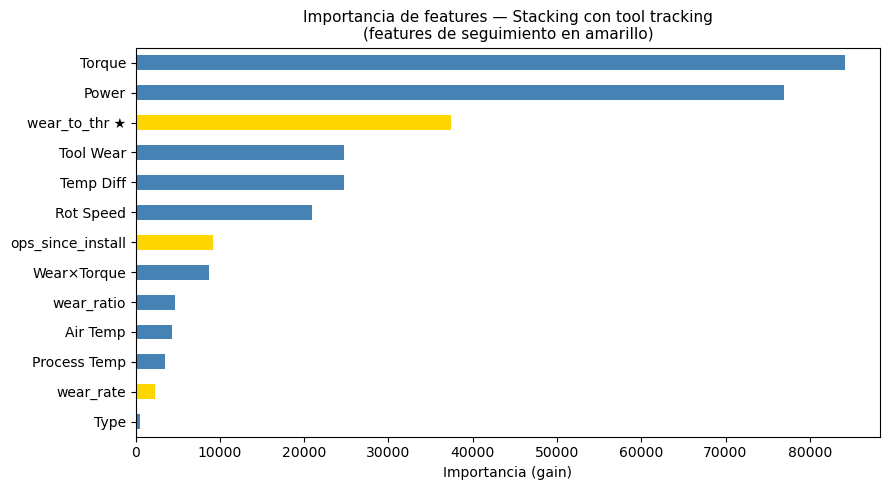

wear_to_threshold ocupa el puesto #3 de 13 features

Top 5 features:
  1. Torque: 84129
  2. Power: 76925
  3. wear_to_thr ★: 37464
  4. Tool Wear: 24678
  5. Temp Diff: 24668


In [8]:
feat_names_v2 = ['Type', 'Air Temp', 'Process Temp', 'Rot Speed', 'Torque',
                 'Tool Wear', 'Power', 'Temp Diff', 'Wear×Torque', 'wear_ratio',
                 'wear_to_thr ★', 'ops_since_install', 'wear_rate']

lgbm_fit = stack_v2.named_estimators_['lgbm']
imp      = pd.Series(lgbm_fit.booster_.feature_importance(importance_type='gain'),
                     index=feat_names_v2).sort_values(ascending=False)

colors = ['gold' if '★' in n or 'ops' in n or 'rate' in n else 'steelblue'
          for n in imp.sort_values().index]
imp.sort_values().plot(kind='barh', figsize=(9, 5), color=colors)
plt.title('Importancia de features — Stacking con tool tracking\n'
          '(features de seguimiento en amarillo)', fontsize=11)
plt.xlabel('Importancia (gain)')
plt.tight_layout()
plt.show()

rank = list(imp.index).index('wear_to_thr ★') + 1
print(f'wear_to_threshold ocupa el puesto #{rank} de {len(imp)} features')
print(f'\nTop 5 features:')
for i,(n,v) in enumerate(imp.items(), 1):
    if i<=5: print(f'  {i}. {n}: {v:.0f}')


## 7. Conclusiones

### Resultados

| | Producción | Con tool tracking | Δ |
|---|---|---|---|
| **Recall** | 0.853 | **0.941** | +0.088 |
| **F1** | 0.913 | **0.948** | +0.035 |
| **ROC-AUC** | 0.975 | **0.995** | +0.020 |
| **FN** | 10 | **4** | −6 fallos |
| **FP** | 1 | 3 | +2 alarmas |

**6 de los 7 fallos invisibles quedan rescatados** al añadir `wear_to_threshold`.

### Por qué funciona

`wear_to_threshold` es exactamente la variable que faltaba:
- Para los TWF: siempre vale `0.0` — la herramienta llegó exactamente a su límite
- Para operaciones normales: media de ~117 min — hay margen de sobra
- La separación es perfecta para los TWF, que es el tipo de fallo que se escapaba

### El fallo que sigue sin detectarse

El 4º FN restante es un fallo que **no es TWF** — pertenece a otro modo de fallo
cuya firma no mejora con el seguimiento de herramienta. Los 3 features nuevos
son específicos para desgaste; no ayudan con HDF, PWF u OSF.

### Lo que significa para producción

Este experimento demuestra que el modelo podría alcanzar **Recall=0.941** si el
sistema de producción registrase:
- `tool_id` — qué herramienta física está instalada
- `tool_threshold` — vida útil asignada a esa herramienta (dato del fabricante)

Ambos datos existen en cualquier sistema CMMS moderno. La limitación actual
no es el modelo — es la disponibilidad del dato.

> **Este notebook es un experimento.** El modelo de producción sigue siendo
> `stacking_best` del notebook `05_01_4_Stacking_AI4I`.
> Este notebook muestra la dirección de mejora, no el modelo desplegado.
